# RPL Points With Two Interfaces

This notebook tests a multi-interface planning case:

- LTE tower-to-device links use the `lte_tower_node` metric.
- Node-to-node links use the `default` metric.
- `itallia` and `torre` are connected devices.
- `deneka` and `saturno` are dual-interface routers.
- `woodland` is a dual-interface leaf test node.
- Other sites are pure LTE leaf devices.

Run one cell at a time so failures show the exact stage that broke.

In [30]:
# Reload session
import importlib
import cisei_lib.planners.graph_planner as gp
import cisei_lib.planners.planner_reports as reports
reports = importlib.reload(reports)
gp = importlib.reload(gp)

In [31]:
from pathlib import Path
import sys

import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "cisei_lib").exists():
    REPO_ROOT = Path("/workspaces/network_service")

sys.path.insert(0, str(REPO_ROOT))

from cisei_lib.io.async_geo_service_pool import AsyncGeoServicePool
from cisei_lib.planners.graph_planner import GraphPlanner
import cisei_lib.planners.planner_reports as reports


CONFIG_PATH = REPO_ROOT / "tests/jupyter/rpl_points_two_interface.toml"
POINTS_PATH = REPO_ROOT / "tests/jupyter/points.csv"

TOWER_IDS = {"itallia", "torre"}
RELAY_IDS = {"deneka", "saturno"}
DUAL_LEAF_IDS = {"woodland"}

## 1. Load Planning Profiles

The TOML defines antenna profiles, interface profiles, device profiles, metric profiles, and connectivity rules.

In [32]:
planner = GraphPlanner.from_toml(CONFIG_PATH, working_crs="EPSG:31982")

print("metric profiles:", sorted(planner.metric_functions_by_tech))
print("interface profiles:", sorted(planner.interface_profiles))
print("device profiles:", sorted(planner.device_profiles))
print("connectivity rules:", len(planner.connectivity_rules))

metric profiles: ['lte', 'n2n']
interface profiles: ['lte_access', 'n2n_leaf', 'n2n_relay']
device profiles: ['dual_leaf', 'dual_router', 'lte_leaf', 'lte_root']
connectivity rules: 3


## 2. Read Site Instances

The CSV only supplies site instances and coordinates. Device profiles are assigned in the notebook.

In [33]:
points = pd.read_csv(POINTS_PATH)
points["id"] = points["id"].astype(str).str.strip()

points

,id,lat,lon,ant_h
0,copel,-25.432731,-49.339207,7
1,tenis,-25.425357,-49.292122,7
2,praca_29,-25.427624,-49.285643,7
3,torre,-25.423532,-49.293992,100
4,woodland,-25.426584,-49.330740,7
5,deneka,-25.423934,-49.325575,7
6,cemiterio,-25.420709,-49.313294,7
7,saturno,-25.427867,-49.343001,7
8,decatlon,-25.428662,-49.322405,7
9,shopping,-25.435108,-49.317711,7


## 3. Assign Device Profiles

Connected sites get the tower/root profile. Selected sites get the dual-router profile. `woodland` gets the dual-leaf profile. Everything else gets the pure LTE leaf profile.

In [34]:
overrides = {
    site_id: {"device_profile": "lte_leaf"}
    for site_id in points["id"]
}

for site_id in TOWER_IDS:
    overrides[site_id] = {"device_profile": "lte_root"}

for site_id in DUAL_LEAF_IDS:
    overrides[site_id] = {"device_profile": "dual_leaf"}

for site_id in RELAY_IDS:
    overrides[site_id] = {"device_profile": "dual_router"}

overrides

{'copel': {'device_profile': 'lte_leaf'},
 'tenis': {'device_profile': 'lte_leaf'},
 'praca_29': {'device_profile': 'lte_leaf'},
 'torre': {'device_profile': 'lte_root'},
 'woodland': {'device_profile': 'dual_leaf'},
 'deneka': {'device_profile': 'dual_router'},
 'cemiterio': {'device_profile': 'lte_leaf'},
 'saturno': {'device_profile': 'dual_router'},
 'decatlon': {'device_profile': 'lte_leaf'},
 'shopping': {'device_profile': 'lte_leaf'},
 'barigui': {'device_profile': 'lte_leaf'},
 'guaira': {'device_profile': 'lte_leaf'},
 'itallia': {'device_profile': 'lte_root'}}

## 4. Instantiate Sites, Devices, and Interfaces

Each physical site becomes one device. Leaf/router devices have two interfaces: LTE and node-to-node.

In [35]:
planner.add_records(points.to_dict("records"), overrides_by_id=overrides)

reports.config_table(planner, "interfaces")

,interface_id,device_id,site_id,tech,freq_mhz,tx_power_dbm,antenna_id,can_relay,medium,interface_profile
0,copel:d0:i0,copel:d0,copel,lte,900.0,43.0,lte_omni,False,rf,lte_access
1,tenis:d0:i0,tenis:d0,tenis,lte,900.0,43.0,lte_omni,False,rf,lte_access
2,praca_29:d0:i0,praca_29:d0,praca_29,lte,900.0,43.0,lte_omni,False,rf,lte_access
3,torre:d0:i0,torre:d0,torre,lte,900.0,43.0,lte_omni,False,rf,lte_access
4,woodland:d0:i0,woodland:d0,woodland,lte,900.0,43.0,lte_omni,False,rf,lte_access
5,woodland:d0:i1,woodland:d0,woodland,n2n,915.0,20.0,n2n_omni,False,rf,n2n_leaf
6,deneka:d0:i0,deneka:d0,deneka,lte,900.0,43.0,lte_omni,False,rf,lte_access
7,deneka:d0:i1,deneka:d0,deneka,n2n,915.0,24.0,n2n_omni,True,rf,n2n_relay
8,cemiterio:d0:i0,cemiterio:d0,cemiterio,lte,900.0,43.0,lte_omni,False,rf,lte_access
9,saturno:d0:i0,saturno:d0,saturno,lte,900.0,43.0,lte_omni,False,rf,lte_access


In [36]:
reports.config_table(planner, "devices")

,device_id,site_id,connected,can_route,rank,mount_height_m,device_profile
0,copel:d0,copel,False,False,inf,7.0,lte_leaf
1,tenis:d0,tenis,False,False,inf,7.0,lte_leaf
2,praca_29:d0,praca_29,False,False,inf,7.0,lte_leaf
3,torre:d0,torre,True,True,0.0,100.0,lte_root
4,woodland:d0,woodland,False,False,inf,7.0,dual_leaf
5,deneka:d0,deneka,False,True,inf,7.0,dual_router
6,cemiterio:d0,cemiterio,False,False,inf,7.0,lte_leaf
7,saturno:d0,saturno,False,True,inf,7.0,dual_router
8,decatlon:d0,decatlon,False,False,inf,7.0,lte_leaf
9,shopping:d0,shopping,False,False,inf,7.0,lte_leaf


## 5. Build Candidate Graph

The generic graph builder uses the TOML connectivity rules. It creates RF links per technology and internal links for devices that route between interfaces.

In [37]:
candidate_edges = planner.build_candidate_edges_from_rules()
print("candidate edges:", len(candidate_edges))

reports.edge_table(planner, "candidate")

candidate edges: 27


,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m
0,torre:d0:i0,tenis:d0:i0,rf,connectivity_0,torre,tenis,lte,lte,900.0,900.0,100.0,7.0
1,torre:d0:i0,praca_29:d0:i0,rf,connectivity_0,torre,praca_29,lte,lte,900.0,900.0,100.0,7.0
2,torre:d0:i0,barigui:d0:i0,rf,connectivity_0,torre,barigui,lte,lte,900.0,900.0,100.0,7.0
3,torre:d0:i0,cemiterio:d0:i0,rf,connectivity_0,torre,cemiterio,lte,lte,900.0,900.0,100.0,7.0
4,torre:d0:i0,shopping:d0:i0,rf,connectivity_0,torre,shopping,lte,lte,900.0,900.0,100.0,7.0
5,torre:d0:i0,guaira:d0:i0,rf,connectivity_0,torre,guaira,lte,lte,900.0,900.0,100.0,7.0
6,torre:d0:i0,decatlon:d0:i0,rf,connectivity_0,torre,decatlon,lte,lte,900.0,900.0,100.0,7.0
7,torre:d0:i0,deneka:d0:i0,rf,connectivity_0,torre,deneka,lte,lte,900.0,900.0,100.0,7.0
8,torre:d0:i0,woodland:d0:i0,rf,connectivity_0,torre,woodland,lte,lte,900.0,900.0,100.0,7.0
9,torre:d0:i0,copel:d0:i0,rf,connectivity_0,torre,copel,lte,lte,900.0,900.0,100.0,7.0


In [38]:
candidate_summary = (
    reports.edge_table(planner, "candidate")
    .groupby(["kind", "src_tech", "dst_tech"])
    .size()
    .rename("edges")
    .reset_index()
)

candidate_summary

,kind,src_tech,dst_tech,edges
0,internal,lte,n2n,2
1,rf,lte,lte,22
2,rf,n2n,n2n,3


## 6. Visualize Candidate Graph

This is the graph offered to RPL before metrics are applied.

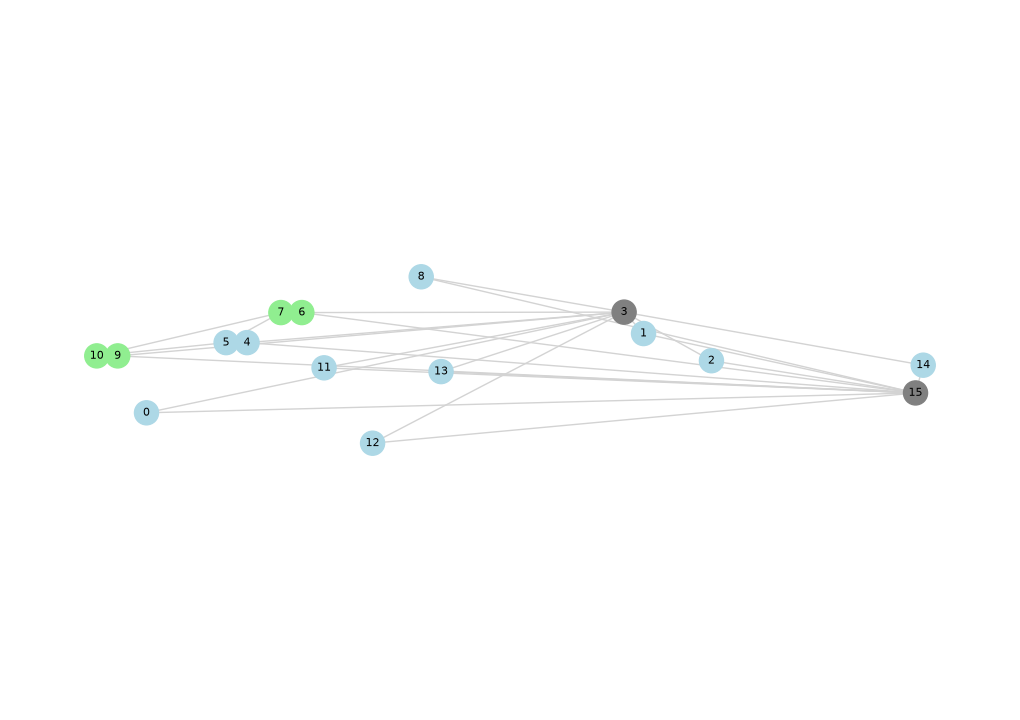

In [39]:
G_candidate = planner.candidate_graph()
reports.draw_network_graph(
    G_candidate,
    label_mode="index",
    spread_same_position=True,
    spread_radius=100,
)

## 7. Compute Real Edge Metrics

The metric is selected by interface technology:

- `lte` -> `lte_tower_node`
- `n2n` -> `default`

The geo service computes environmental features. `GraphPlanner` enriches them with `tx`, `rx`, and nested `features` before calling the metric compiler.

In [40]:
geo = AsyncGeoServicePool(
    base_url="http://planning-service:8080",
    user_prefix="rpl-two-interface",
    pool_size=2,
    timeout=120,
)

edge_metrics = await planner.compute_edge_metrics(
    geo,
    manage_geo=True,
)

print("computed edge metrics:", len(edge_metrics))

APIResult(kind='json')
APIResult(kind='json')
APIResult(kind='json')
computed edge metrics: 27


In [41]:
reports.edge_table(planner, "metric").head(20)

,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m,metric
0,deneka:d0:i0,deneka:d0:i1,internal,connectivity_2,deneka,deneka,lte,n2n,900.0,915.0,7.0,7.0,0.000000
1,saturno:d0:i0,saturno:d0:i1,internal,connectivity_2,saturno,saturno,lte,n2n,900.0,915.0,7.0,7.0,0.000000
2,torre:d0:i0,tenis:d0:i0,rf,connectivity_0,torre,tenis,lte,lte,900.0,900.0,100.0,7.0,1.000000
3,torre:d0:i0,praca_29:d0:i0,rf,connectivity_0,torre,praca_29,lte,lte,900.0,900.0,100.0,7.0,1.000000
4,torre:d0:i0,barigui:d0:i0,rf,connectivity_0,torre,barigui,lte,lte,900.0,900.0,100.0,7.0,1.000000
5,torre:d0:i0,cemiterio:d0:i0,rf,connectivity_0,torre,cemiterio,lte,lte,900.0,900.0,100.0,7.0,1.000000
6,torre:d0:i0,copel:d0:i0,rf,connectivity_0,torre,copel,lte,lte,900.0,900.0,100.0,7.0,1.000000
7,itallia:d0:i0,guaira:d0:i0,rf,connectivity_0,itallia,guaira,lte,lte,900.0,900.0,30.0,7.0,1.000000
8,saturno:d0:i1,woodland:d0:i1,rf,connectivity_1,saturno,woodland,n2n,n2n,915.0,915.0,7.0,7.0,1.000000
9,torre:d0:i0,decatlon:d0:i0,rf,connectivity_0,torre,decatlon,lte,lte,900.0,900.0,100.0,7.0,1.468871


## 8. Inspect One Metric Record

This shows the exact structure passed into the metric compiler for one edge.

In [42]:
first_edge = next(iter(planner.edge_features))
first_edge, planner.edge_features[first_edge]

(('torre:d0:i0', 'tenis:d0:i0'),
 {'tx': {'ant_gain': 6.0, 'ant_height': 100.0, 'ant_type': 'omni', 'pw': 43.0},
  'rx': {'ant_gain': 6.0, 'ant_height': 7.0, 'ant_type': 'omni'},
  'features': {'fspl': 85.35,
   'dist_m': 276.1,
   'delta_diffra': 0,
   'terrain': {'core': 0, 'fresnel': 0, 'boundary': 0},
   'vegetation': {'core': 0, 'fresnel': 0, 'boundary': 0},
   'buildings': {'core': 0, 'fresnel': 0, 'boundary': 0},
   'terrain_peaks_vv': [],
   'max_obstruction_angle_rad': 0,
   'tx_rx_elevation_angle_rad': -0.32,
   'tx_near_terminal_clearance_m': 83.88,
   'rx_near_terminal_clearance_m': 17.67,
   'freq_mhz': 900.0}})

## 9. Run RPL

RPL sees interfaces as nodes and edge metrics as already-computed costs.

In [43]:
rpl = planner.run_rpl()
planner.rpl_result_counts()

{'nodes': 16, 'edges': 14}

In [51]:
reports.node_table(planner, "result")

,node_index,node_id,site_id,device_id,parent,parent_index,parent_site_id,connected,rpl_relay,rank,interface_can_relay,can_relay
0,0,copel:d0:i0,copel,copel:d0,torre:d0:i0,3.0,torre,False,False,1.000000,False,False
1,1,tenis:d0:i0,tenis,tenis:d0,torre:d0:i0,3.0,torre,False,False,1.000000,False,False
2,2,praca_29:d0:i0,praca_29,praca_29:d0,torre:d0:i0,3.0,torre,False,False,1.000000,False,False
3,3,torre:d0:i0,torre,torre:d0,NaN,NaN,NaN,True,True,0.000000,False,False
4,4,woodland:d0:i0,woodland,woodland:d0,torre:d0:i0,3.0,torre,False,False,10.020646,False,False
5,5,woodland:d0:i1,woodland,woodland:d0,saturno:d0:i1,10.0,saturno,False,False,3.606353,False,False
6,6,deneka:d0:i0,deneka,deneka:d0,torre:d0:i0,3.0,torre,False,True,2.040680,False,False
7,7,deneka:d0:i1,deneka,deneka:d0,deneka:d0:i0,6.0,deneka,False,True,2.040680,True,True
8,8,cemiterio:d0:i0,cemiterio,cemiterio:d0,torre:d0:i0,3.0,torre,False,False,1.000000,False,False
9,9,saturno:d0:i0,saturno,saturno:d0,torre:d0:i0,3.0,torre,False,True,2.606353,False,False


In [ ]:
reports.edge_table(planner, "metric")

In [50]:
reports.edge_table(planner, "result")

,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m,metric
0,copel:d0:i0,torre:d0:i0,rf,connectivity_0,copel,torre,lte,lte,900.0,900.0,7.0,100.0,1.000000
1,tenis:d0:i0,torre:d0:i0,rf,connectivity_0,tenis,torre,lte,lte,900.0,900.0,7.0,100.0,1.000000
2,praca_29:d0:i0,torre:d0:i0,rf,connectivity_0,praca_29,torre,lte,lte,900.0,900.0,7.0,100.0,1.000000
3,torre:d0:i0,woodland:d0:i0,rf,connectivity_0,torre,woodland,lte,lte,900.0,900.0,100.0,7.0,10.020646
4,torre:d0:i0,deneka:d0:i0,rf,connectivity_0,torre,deneka,lte,lte,900.0,900.0,100.0,7.0,2.040680
5,torre:d0:i0,cemiterio:d0:i0,rf,connectivity_0,torre,cemiterio,lte,lte,900.0,900.0,100.0,7.0,1.000000
6,torre:d0:i0,saturno:d0:i0,rf,connectivity_0,torre,saturno,lte,lte,900.0,900.0,100.0,7.0,2.606353
7,torre:d0:i0,decatlon:d0:i0,rf,connectivity_0,torre,decatlon,lte,lte,900.0,900.0,100.0,7.0,1.468871
8,torre:d0:i0,shopping:d0:i0,rf,connectivity_0,torre,shopping,lte,lte,900.0,900.0,100.0,7.0,1.493932
9,torre:d0:i0,barigui:d0:i0,rf,connectivity_0,torre,barigui,lte,lte,900.0,900.0,100.0,7.0,1.000000


## 10. Visualize RPL Result

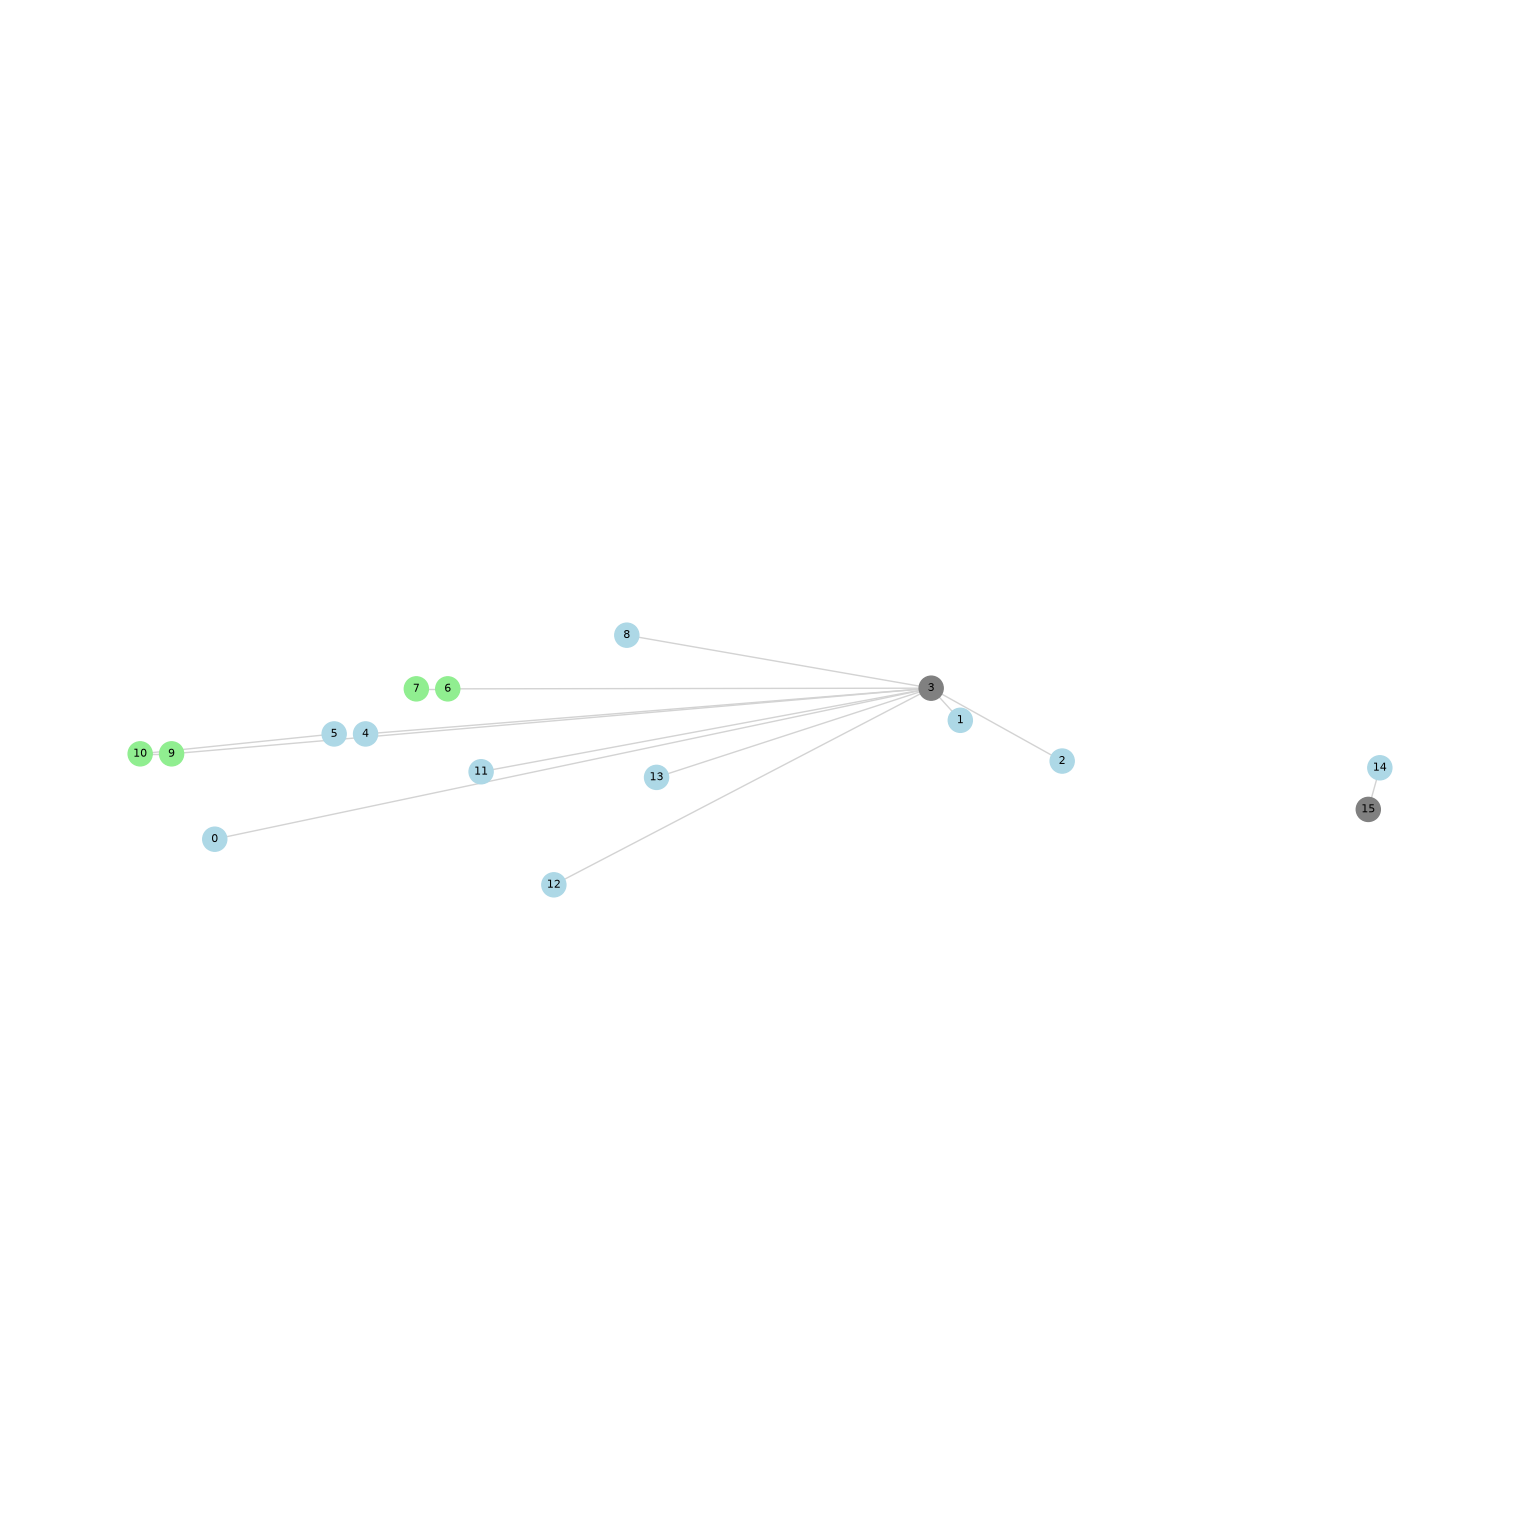

In [53]:
reports.draw_network_graph(
    planner.rpl.G_res,
    label_mode="index",
    figsize=(15, 15),
    spread_same_position=True,
    spread_radius=100,
)